# Decomposition Workflow
# $H \to DLA \to e^{i \rho t} \to BDI \to U_{\text{reconstructed}}$

In [1]:
import numpy as np

## Choose model and decomposition parameters
This cell sets the TFIM model size and evolution time.
You can change n, J, h, t and periodic according to your experiment. We remind that we are working with the Hamiltonian:
$
\begin{equation}
    H = -J \sum^{N-2}_{i=0}Z_iZ_{i+1} -h \sum^{N-1}_{i=0}X_i,
\end{equation}
$

In [2]:
# Model parameters
n = 8
J = 1.0
h = 1.0
t = 0.5
rotated = True
periodic = False

print(f"n = {n}, J = {J}, h = {h}, t = {t}, rotated = {rotated}, periodic = {periodic}")

n = 8, J = 1.0, h = 1.0, t = 0.5, rotated = True, periodic = False


In [3]:
from build_TFIM import TFIM_Ham

if n <= 10:
    hamiltonian = TFIM_Ham(n)
    print(f"Hamiltonian shape: {hamiltonian.shape}")
    print(hamiltonian)

Hamiltonian shape: (256, 256)
[[-8.  0.  0. ...  0.  0.  0.]
 [ 0. -6. -1. ...  0.  0.  0.]
 [ 0. -1. -6. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  6. -1.  0.]
 [ 0.  0.  0. ... -1.  6.  0.]
 [ 0.  0.  0. ...  0.  0.  8.]]


## Build DLA generators (Pauli-word form)
We generate TFIM Pauli words and grow the DLA closure.

In [4]:
from find_DLA import tfim_pauliwords_gen, dla_pauli_words

generators = tfim_pauliwords_gen(n, rotated=rotated, periodic=periodic)
dla_words = dla_pauli_words(generators)

print("Initial generators:", len(generators))
print("DLA size:", len(dla_words))
print("First few DLA words:", dla_words[:3])

Initial generators: 15
DLA size: 120
First few DLA words: [('X', 'X', 'I', 'I', 'I', 'I', 'I', 'I'), ('I', 'X', 'X', 'I', 'I', 'I', 'I', 'I'), ('I', 'I', 'X', 'X', 'I', 'I', 'I', 'I')]


## Map to the Majorana/isomorphic so(2n) matrix
This creates the isomorphism $\rho(iH)$ used before exponentiation.

In [5]:
from build_isomorphism import map_to_majarana, build_so_matrix

maj_mapping = map_to_majarana(generators, J=J, h=h)
print(maj_mapping)
rho_iH = build_so_matrix(maj_mapping, n)

print("rho(iH) shape:", rho_iH.shape)
print("rho(iH) skew Hermitian?", np.allclose(rho_iH.T, -rho_iH, atol=1e-10))
print(rho_iH)

{('X', 'X', 'I', 'I', 'I', 'I', 'I', 'I'): (1.0, (0, 3)), ('I', 'X', 'X', 'I', 'I', 'I', 'I', 'I'): (1.0, (2, 5)), ('I', 'I', 'X', 'X', 'I', 'I', 'I', 'I'): (1.0, (4, 7)), ('I', 'I', 'I', 'X', 'X', 'I', 'I', 'I'): (1.0, (6, 9)), ('I', 'I', 'I', 'I', 'X', 'X', 'I', 'I'): (1.0, (8, 11)), ('I', 'I', 'I', 'I', 'I', 'X', 'X', 'I'): (1.0, (10, 13)), ('I', 'I', 'I', 'I', 'I', 'I', 'X', 'X'): (1.0, (12, 15)), ('Z', 'I', 'I', 'I', 'I', 'I', 'I', 'I'): (-1.0, (0, 1)), ('I', 'Z', 'I', 'I', 'I', 'I', 'I', 'I'): (-1.0, (2, 3)), ('I', 'I', 'Z', 'I', 'I', 'I', 'I', 'I'): (-1.0, (4, 5)), ('I', 'I', 'I', 'Z', 'I', 'I', 'I', 'I'): (-1.0, (6, 7)), ('I', 'I', 'I', 'I', 'Z', 'I', 'I', 'I'): (-1.0, (8, 9)), ('I', 'I', 'I', 'I', 'I', 'Z', 'I', 'I'): (-1.0, (10, 11)), ('I', 'I', 'I', 'I', 'I', 'I', 'Z', 'I'): (-1.0, (12, 13)), ('I', 'I', 'I', 'I', 'I', 'I', 'I', 'Z'): (-1.0, (14, 15))}
rho(iH) shape: (16, 16)
rho(iH) skew Hermitian? True
[[ 0. -2.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.

## Exponentiate to get the matrix to decompose
Now build $U(t)=\exp(t\,\rho(iH))$ and verify unitarity/orthogonality.

In [6]:
from BDI_decomp import from_generator

U_t = from_generator(rho_iH, t=t)

print("U(t) shape:", U_t.shape)
print("Is U(t) unitary?", np.allclose(U_t @ U_t.conj().T, np.eye(U_t.shape[0]), atol=1e-10))
print("Is U(t) real (orthogonal case)?", np.allclose(U_t.imag, 0.0, atol=1e-10))

U(t) shape: (16, 16)
Is U(t) unitary? True
Is U(t) real (orthogonal case)? True


## One-step BDI KAK decomposition
Decompose $U(t)$ one step, rebuild $K_1 A K_2$, and check reconstruction error to verify BDI.

In [7]:
from BDI_decomp import bdi, build_kak

k11, k12, theta, k21, k22 = bdi(U_t)
K1, A, K2 = build_kak(k11, k12, theta, k21, k22)
U_rec = K1 @ A @ K2

print("K1 shape:", K1.shape, "A shape:", A.shape, "K2 shape:", K2.shape)
print("One-step reconstruction allclose:", np.allclose(U_t, U_rec, atol=1e-10))
print("Max reconstruction error:", np.max(np.abs(U_t - U_rec)))

K1 shape: (16, 16) A shape: (16, 16) K2 shape: (16, 16)
One-step reconstruction allclose: True
Max reconstruction error: 7.771561172376096e-16


## Recursive BDI
Run the recursive factorization and print operation counts by type.

In [8]:
from BDI_decomp import recursive_bdi

ops = recursive_bdi(U_t, num_iter=None, return_all=False) # This cell needs return_all=False to get the final list of ops
print("Total recursive ops:", len(ops))

types = {}
for _, _, _, op_type in ops:
    types[op_type] = types.get(op_type, 0) + 1

print("Operation type counts:")
for k in sorted(types, key=lambda x: str(x)):
    print(f" {k}: {types[k]}")

print(ops)

"""
Check wether we need to transpose the k's, where is sin and cos on diagonal or off diagonal...
"""

Total recursive ops: 85
Operation type counts:
 a: 20
 a0: 1
 k1: 32
 k2: 32
[(array([[-0.19210778, -0.98137383],
       [ 0.98137383, -0.19210778]]), 0, 2, 'k1'), (array([[ 0.99557447, -0.09397588],
       [ 0.09397588,  0.99557447]]), 2, 4, 'k1'), (array([0.00181454, 0.29905797]), 0, 4, 'a'), (array([[ 0.99162676, -0.12913704],
       [ 0.12913704,  0.99162676]]), 0, 2, 'k2'), (array([[-0.18873734, -0.98202761],
       [ 0.98202761, -0.18873734]]), 2, 4, 'k2'), (array([[ 0.99736061, -0.07260724],
       [ 0.07260724,  0.99736061]]), 4, 6, 'k1'), (array([[-0.06093094, -0.99814198],
       [ 0.99814198, -0.06093094]]), 6, 8, 'k1'), (array([1.40268213, 1.57054717]), 4, 8, 'a'), (array([[ 0.04076899,  0.9991686 ],
       [-0.9991686 ,  0.04076899]]), 4, 6, 'k2'), (array([[-0.98923578,  0.14633032],
       [-0.14633032, -0.98923578]]), 6, 8, 'k2'), (array([3.14159269e+00, 3.37604212e-05, 1.00111045e-02, 4.90966180e-01]), 0, 8, 'a'), (array([[ 0.99759154,  0.06936217],
       [-0.06936217,

"\nCheck wether we need to transpose the k's, where is sin and cos on diagonal or off diagonal...\n"

In [9]:
from BDI_verification import verify_bdi_decomposition
verify_bdi_decomposition(U_t, ops)

Max reconstruction error: 9.992007221626409e-16
Recursive allclose: True


In [10]:
# Print out the determinants of the K1, A, K2 to check if they are in SO(2n) or O(2n)
det_1 = 0
det_m1 = 0
for element in ops:
    if element[3] in ['k1', 'k2']:
        det = np.linalg.det(element[0])
        #print(f"{element[3]} determinant: {det:.4f}")
        if det > 0.5:
            det_1 += 1
        else:
            det_m1 += 1
print(f"Number of K1/K2 with determinant +1: {det_1}")
print(f"Number of K1/K2 with determinant -1: {det_m1}")

Number of K1/K2 with determinant +1: 64
Number of K1/K2 with determinant -1: 0


## Map Back to Pauli Rotations

In [11]:
from map_back import pw_to_majorana, build_majorana_dla_map, map_ops_to_pauli


In [12]:
mapping = build_majorana_dla_map(dla_words)
print(f"Majorana DLA map size: {len(mapping)}")


Majorana DLA map size: 120


In [13]:
pauli_decomp = map_ops_to_pauli(ops, mapping, time=t)
print(f"Pauli decomposition: {len(pauli_decomp)} gates (expected n(2n-1) = {n*(2*n-1)})")

by_stage = {}
by_weight = {}
for word, _, op_type in pauli_decomp:
    by_stage[op_type] = by_stage.get(op_type, 0) + 1
    w = sum(1 for p in word if p != "I")
    by_weight[w] = by_weight.get(w, 0) + 1

print(f"By stage:  {by_stage}")
print(f"By weight: { {k: by_weight[k] for k in sorted(by_weight)} }")

Pauli decomposition: 120 gates (expected n(2n-1) = 120)
By stage:  {'k1': 32, 'a': 48, 'k2': 32, 'a0': 8}
By weight: {1: 64, 2: 32, 3: 16, 5: 8}


## Verify Reconstruction

In [14]:
from scipy.linalg import expm

if n <= 8:
    # Pauli Matrix Builders
    I2 = np.eye(2, dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)

    Pauli_matrices = {"I": I2, "X": X, "Y": Y, "Z": Z}

    # Function to convert a Pauli word to its matrix representation
    def pauli_word_to_matrix(pw):
        mat = Pauli_matrices[pw[0]]
        for p in pw[1:]:
            mat = np.kron(mat, Pauli_matrices[p])
        return mat

    def pauli_rotation(word, coeff):
        P = pauli_word_to_matrix(word)
        return expm(-1.0j * coeff * P)

    U_rec_pauli = np.eye(2**n, dtype=complex)

    for word, coeff, op_type in (pauli_decomp):
        gate = pauli_rotation(word, coeff)
        U_rec_pauli = gate @ U_rec_pauli


Raw matrix close? False
Raw norm difference: 31.999999999999687
Global phase offset (rad): 3.141592653589793

Close up to global phase? True
Phase-aligned norm difference: 1.8938970778435354e-13


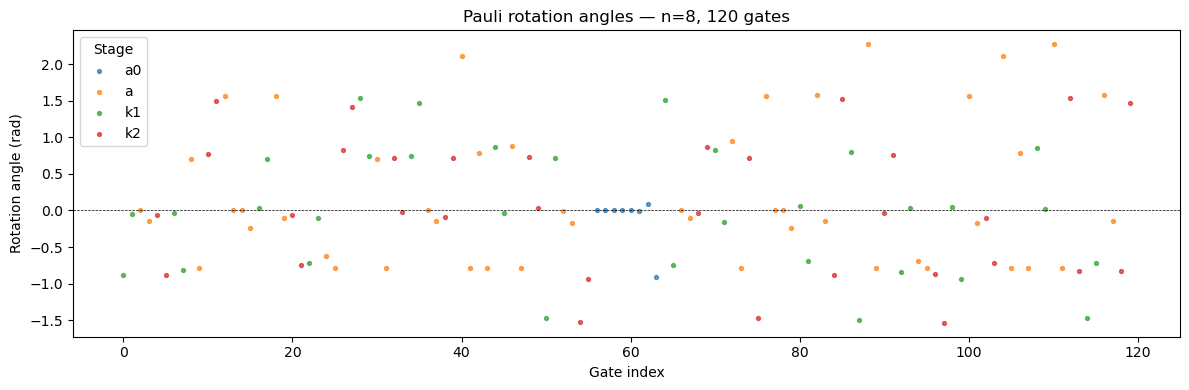

In [15]:
import pennylane as qml
import matplotlib.pyplot as plt

def pauli_word_to_string(pw):
    return "".join(p for p in pw if p != "I")

def pauli_word_to_wires(pw):
    return [i for i, p in enumerate(pw) if p != "I"]

paulirot_decomp = [
    (coeff, pauli_word_to_string(pw), pauli_word_to_wires(pw), typ)
    for pw, coeff, typ in pauli_decomp
]

def kak_time_evolution(time):
    for coeff, pauli_str, wires, typ in paulirot_decomp[::-1]:
        if typ == "a0":
            coeff = coeff * time  # re-scales the divided-out t back in
        qml.PauliRot(2 * coeff, pauli_str, wires=wires)


def phase_align_error(U_ref, U_test):
    d = U_ref.shape[0]
    phase = np.angle(np.trace(U_test @ U_ref.conj().T) / d)
    U_aligned = np.exp(-1j * phase) * U_test
    return phase, np.linalg.norm(U_ref - U_aligned), np.allclose(U_ref, U_aligned, atol=1e-8)


dev = qml.device("default.qubit", wires=n)

@qml.qnode(dev)
def circuit(time):
    kak_time_evolution(time)
    return qml.state()

if n <= 8:
    U_Hamiltonian = expm(-1.0j * hamiltonian * t)
    U_circ = qml.matrix(circuit)(t)

    raw_close = np.allclose(U_Hamiltonian, U_circ, atol=1e-8)
    raw_norm = np.linalg.norm(U_Hamiltonian - U_circ)
    phase, aligned_norm, aligned_close = phase_align_error(U_Hamiltonian, U_circ)

    print(f"Raw matrix close? {raw_close}")
    print(f"Raw norm difference: {raw_norm}")
    print(f"Global phase offset (rad): {phase}")
    print(f"\nClose up to global phase? {aligned_close}")
    print(f"Phase-aligned norm difference: {aligned_norm}")
else:
    print(f"n={n} > 10: full Hilbert space verification skipped.")

# Circuit visualisation: draw for small n, angle scatter plot for large n
if n <= 6:
    print("\nCircuit:")
    qml.draw_mpl(circuit)(t)
    plt.show()
else:
    stage_order = ["a0", "a", "k1", "k2"]
    stage_colors = {"a0": "tab:blue", "a": "tab:orange", "k1": "tab:green", "k2": "tab:red"}

    fig, ax = plt.subplots(figsize=(12, 4))
    for stage in stage_order:
        xs = [i for i, (_, _, typ) in enumerate(pauli_decomp) if typ == stage]
        ys = [pauli_decomp[i][1] for i in xs]
        ax.scatter(xs, ys, s=8, alpha=0.7, color=stage_colors[stage], label=stage)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Gate index")
    ax.set_ylabel("Rotation angle (rad)")
    ax.set_title(f"Pauli rotation angles — n={n}, {len(pauli_decomp)} gates")
    ax.legend(title="Stage")
    plt.tight_layout()
    plt.show()